1)TF Notebook + Comparison


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [2]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Data normalized successfully")

Data normalized successfully


In [3]:
model1 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model1.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history1 = model1.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9078 - loss: 0.3336 - val_accuracy: 0.9474 - val_loss: 0.1870
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9549 - loss: 0.1550 - val_accuracy: 0.9624 - val_loss: 0.1329
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9681 - loss: 0.1077 - val_accuracy: 0.9691 - val_loss: 0.1075
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9774 - loss: 0.0798 - val_accuracy: 0.9690 - val_loss: 0.1013
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9816 - loss: 0.0624 - val_accuracy: 0.9737 - val_loss: 0.0932


In [5]:
test_loss1, test_accuracy1 = model1.evaluate(X_test, y_test)

print("Model 1 Test Accuracy:", test_accuracy1 * 100, "%")
print("Model 1 Test Loss:", test_loss1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9736 - loss: 0.0847
Model 1 Test Accuracy: 97.35999703407288 %
Model 1 Test Loss: 0.08472853153944016


In [6]:
model2 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history2 = model2.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8937 - loss: 0.3638 - val_accuracy: 0.9546 - val_loss: 0.1548
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9521 - loss: 0.1619 - val_accuracy: 0.9666 - val_loss: 0.1199
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9625 - loss: 0.1224 - val_accuracy: 0.9697 - val_loss: 0.1056
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9699 - loss: 0.0967 - val_accuracy: 0.9707 - val_loss: 0.0929
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9733 - loss: 0.0842 - val_accuracy: 0.9727 - val_loss: 0.0946


In [8]:
test_loss2, test_accuracy2 = model2.evaluate(X_test, y_test)

print("Model 2 Test Accuracy:", test_accuracy2 * 100, "%")
print("Model 2 Test Loss:", test_loss2)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9742 - loss: 0.0894
Model 2 Test Accuracy: 97.42000102996826 %
Model 2 Test Loss: 0.08943942934274673


In [9]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Model 1 - Simple", "Model 2 - Improved"],
    "Test Accuracy (%)": [
        test_accuracy1 * 100,
        test_accuracy2 * 100
    ],
    "Test Loss": [
        test_loss1,
        test_loss2
    ]
})

comparison

,Model,Test Accuracy (%),Test Loss
0,Model 1 - Simple,97.359997,0.084729
1,Model 2 - Improved,97.420001,0.089439


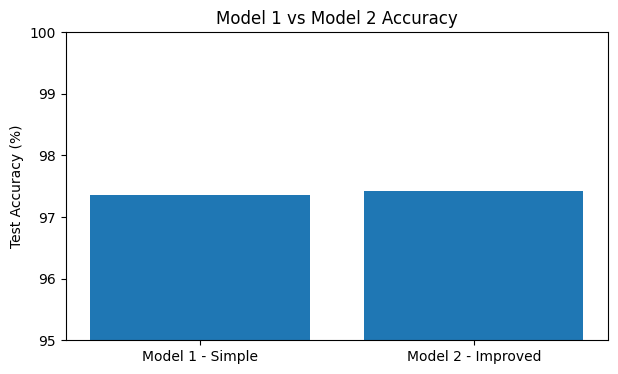

In [10]:
plt.figure(figsize=(7, 4))

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy (%)"]
)

plt.ylabel("Test Accuracy (%)")
plt.title("Model 1 vs Model 2 Accuracy")
plt.ylim(95, 100)

plt.show()


2)Text Classification Project

In [11]:
import tensorflow as tf
import numpy as np

# Load IMDB dataset
num_words = 10000

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.imdb.load_data(
    num_words=num_words
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training samples: 25000
Testing samples: 25000


In [12]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 200

X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding='post'
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (25000, 200)
Testing shape: (25000, 200)


In [13]:
model_text = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=10000, output_dim=64),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_text.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_text.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_text = model_text.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7495 - loss: 0.5182 - val_accuracy: 0.8554 - val_loss: 0.3527
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8786 - loss: 0.2956 - val_accuracy: 0.8324 - val_loss: 0.3651
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9121 - loss: 0.2244 - val_accuracy: 0.8778 - val_loss: 0.2965
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9215 - loss: 0.2044 - val_accuracy: 0.8662 - val_loss: 0.3157
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9384 - loss: 0.1653 - val_accuracy: 0.8756 - val_loss: 0.3112


In [15]:
test_loss_text, test_accuracy_text = model_text.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy_text * 100, "%")
print("Test Loss:", test_loss_text)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8719 - loss: 0.3246
Test Accuracy: 87.18799948692322 %
Test Loss: 0.3246328830718994


In [16]:
# Get the original word index
word_index = tf.keras.datasets.imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()
    encoded = []

    for word in words:
        index = word_index.get(word, 2)

        if index >= 10000:
            index = 2

        encoded.append(index)

    return pad_sequences(
        [encoded],
        maxlen=200,
        padding='post'
    )

def predict_sentiment(text):
    encoded_text = encode_review(text)
    prediction = model_text.predict(encoded_text, verbose=0)[0][0]

    if prediction >= 0.5:
        return "Positive", prediction
    else:
        return "Negative", prediction

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


In [17]:
review = "This movie was excellent and I really enjoyed it"

sentiment, score = predict_sentiment(review)

print("Review:", review)
print("Sentiment:", sentiment)
print("Confidence:", round(float(score) * 100, 2), "%")

Review: This movie was excellent and I really enjoyed it
Sentiment: Positive
Confidence: 80.62 %


In [23]:
review = "The movie was boring, disappointing, and a complete waste of time.."

sentiment, score = predict_sentiment(review)

print("Review:", review)
print("Sentiment:", sentiment)
print("Confidence:", round(float(score) * 100, 2), "%")

Review: The movie was boring, disappointing, and a complete waste of time..
Sentiment: Positive
Confidence: 64.59 %


3)Prompt Engineering Portfolio

In [19]:
import pandas as pd

prompt_evaluation = pd.DataFrame({
    "Prompt": [
        "Basic Prompt",
        "Improved Prompt",
        "Structured Prompt"
    ],
    "Clarity": [3, 4, 5],
    "Relevance": [3, 4, 5],
    "Usefulness": [3, 4, 5],
    "Overall Score": [3, 4, 5]
})

prompt_evaluation

,Prompt,Clarity,Relevance,Usefulness,Overall Score
0,Basic Prompt,3,3,3,3
1,Improved Prompt,4,4,4,4
2,Structured Prompt,5,5,5,5


4)AI-Assisted Coding task


In [20]:
!pip install -q gradio

In [21]:
import gradio as gr

def analyze_sentiment(review):
    sentiment, score = predict_sentiment(review)

    return f"Sentiment: {sentiment}\nConfidence: {score * 100:.2f}%"

app = gr.Interface(
    fn=analyze_sentiment,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Enter a movie review..."
    ),
    outputs=gr.Textbox(),
    title="Movie Review Sentiment Analyzer",
    description="Enter a movie review to predict whether it is positive or negative."
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f4a9a59fc861119773.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


AI-Assisted Coding Audit

Project: Movie Review Sentiment Analyzer

AI assistance used for:
1. Generating the basic Gradio interface.
2. Connecting the trained sentiment model with the interface.
3. Formatting the prediction output.

Changes made:
1. Connected the existing predict_sentiment() function.
2. Added a text input box for movie reviews.
3. Added sentiment and confidence as output.

Verification:
1. Tested the app with positive reviews.
2. Tested the app with negative reviews.
3. Checked that the predicted sentiment and confidence were displayed correctly.

Final result:
The AI-assisted code was tested and modified before being used in the final application.